In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

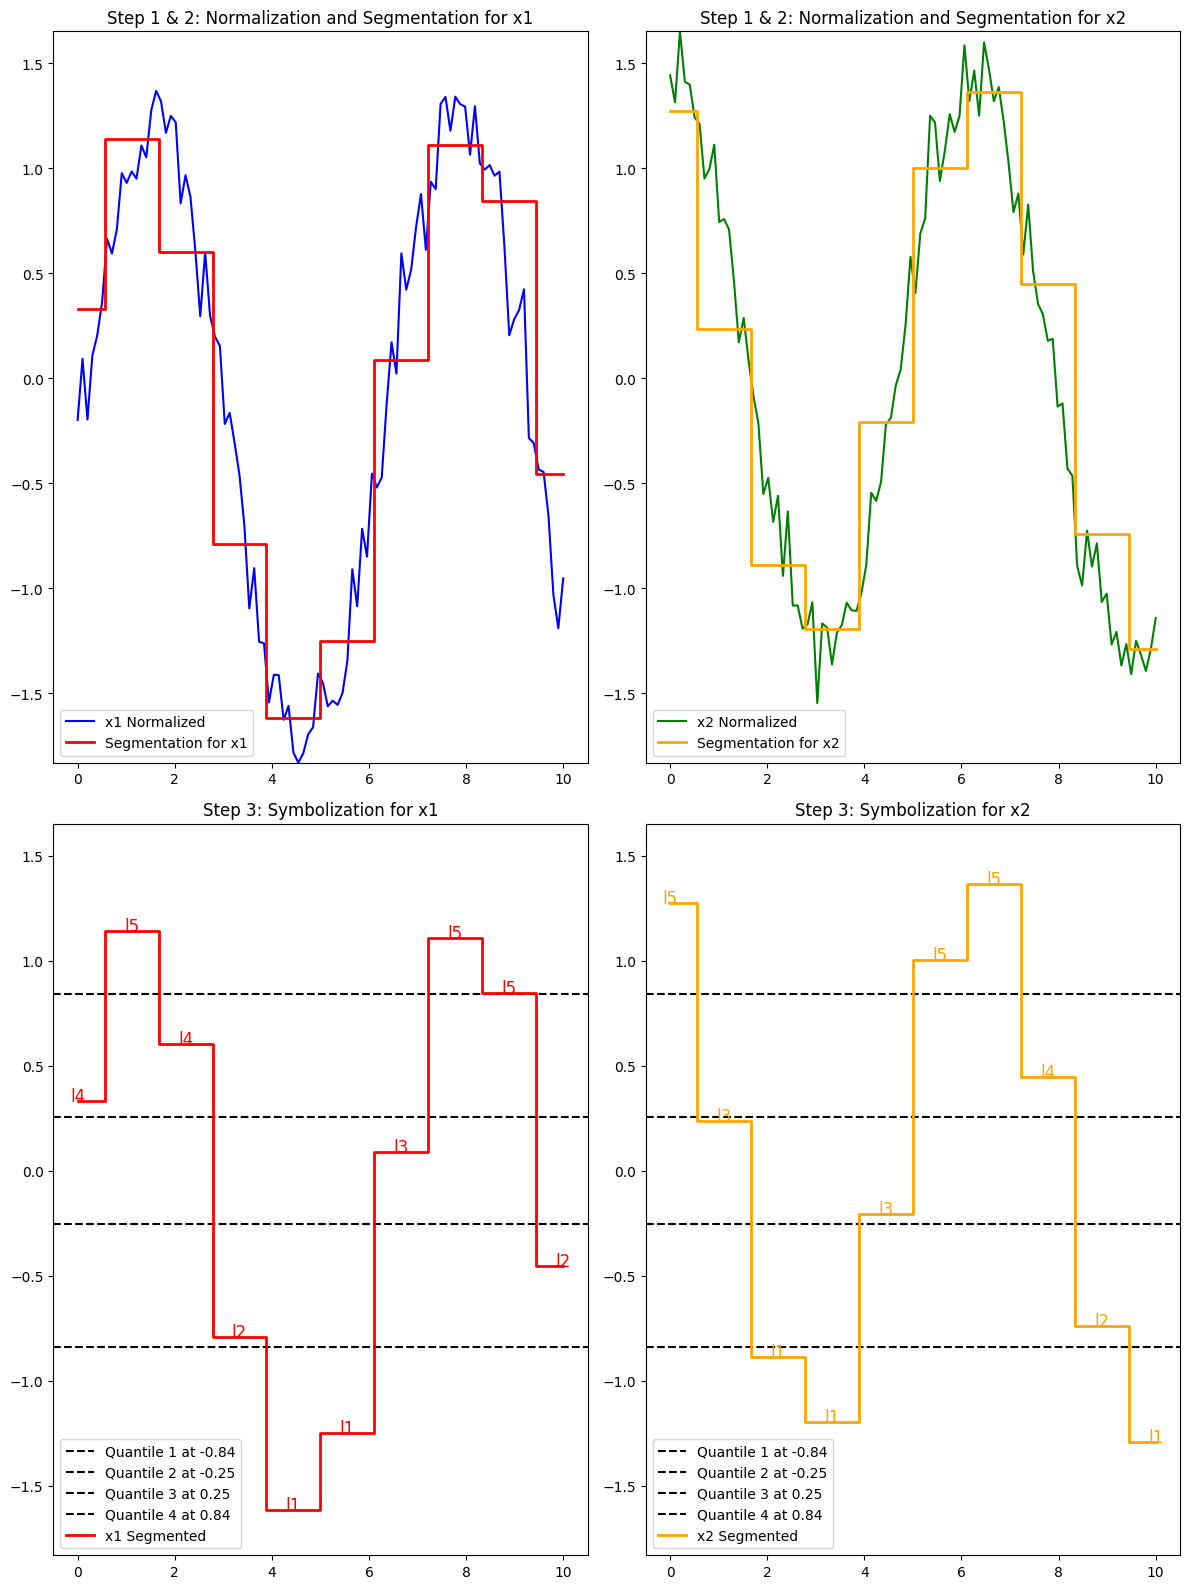

SAX Distance: 7.918


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.distances import sax_distance

# Generate time series
t = np.linspace(0, 10, 100)
x1 = np.sin(t) + np.random.normal(0, 0.1, 100)
x2 = np.cos(t) + np.random.normal(0, 0.1, 100)

# Normalize the signals
x1_normalized = (x1 - np.mean(x1)) / np.std(x1)
x2_normalized = (x2 - np.mean(x2)) / np.std(x2)

# Segmentation (assuming each segment has 10 data points)
segment_length = 10
x1_segments = [np.mean(x1_normalized[i:i+segment_length]) for i in range(0, len(x1_normalized), segment_length)]
x2_segments = [np.mean(x2_normalized[i:i+segment_length]) for i in range(0, len(x2_normalized), segment_length)]
t_segments = np.linspace(0, 10, len(x1_segments))

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot normalized time series and segmentation (Step 1 and Step 2)
axs[0].plot(t, x1_normalized, label='x1 Normalized', color='blue', linestyle='-', markersize=5)
axs[1].plot(t, x2_normalized, label='x2 Normalized', color='green', linestyle='-', markersize=5)
axs[0].step(t_segments, x1_segments, label='Segmentation for x1', color='red', linewidth=2, where='mid')
axs[1].step(t_segments, x2_segments, label='Segmentation for x2', color='orange', linewidth=2, where='mid')

axs[0].set_title('Step 1 & 2: Normalization and Segmentation for x1')
axs[1].set_title('Step 1 & 2: Normalization and Segmentation for x2')
axs[0].legend(loc='lower left')
axs[1].legend(loc='lower left')

# Ensure the y-axis range is the same for both plots
y_min = min(np.min(x1_normalized), np.min(x2_normalized))
y_max = max(np.max(x1_normalized), np.max(x2_normalized))
axs[0].set_ylim(y_min, y_max)
axs[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

# Calculate the overall SAX distance
num_symbols = 5
sax_distance_value = sax_distance(x1, x2, word_size=len(x1_segments), alphabet_size=num_symbols)
print(f"SAX Distance: {sax_distance_value:.3f}")
